In [1]:
%cd ..

/home/blanka/Multi-Domain-Pruning


/data/blanka/virtualenvs/yolov10/lib/python3.12/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [10]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from reinforcement_learning.rewards import reward_function_proposed


In [33]:
def plot_reward_surface(Tspars, Tdmap, spars_coeff, dmap_coeff, beta=5, device="cpu", resolution=100):
    # 1. Reward vs spars (fixed dmap)
    spars_vals = np.linspace(0, 1, resolution)
    spars_tensor = torch.tensor(spars_vals, dtype=torch.float32, device=device)
    dmap_fixed = torch.full_like(spars_tensor, Tdmap)
    reward_spars = reward_function_proposed(spars_tensor, Tspars, dmap_fixed, Tdmap, spars_coeff, dmap_coeff, beta).cpu().numpy()

    # 2. Reward vs dmap (fixed spars)
    dmap_vals = np.linspace(0, 1, resolution)
    dmap_tensor = torch.tensor(dmap_vals, dtype=torch.float32, device=device)
    spars_fixed = torch.full_like(dmap_tensor, Tspars)
    reward_dmap = reward_function_proposed(spars_fixed, Tspars, dmap_tensor, Tdmap, spars_coeff, dmap_coeff, beta).cpu().numpy()

    # 3. Reward vs (spars, dmap)
    spars_grid, dmap_grid = np.meshgrid(spars_vals, dmap_vals)
    spars_grid_tensor = torch.tensor(spars_grid, dtype=torch.float32, device=device)
    dmap_grid_tensor = torch.tensor(dmap_grid, dtype=torch.float32, device=device)
    reward_grid = reward_function_proposed(spars_grid_tensor, Tspars, dmap_grid_tensor, Tdmap, spars_coeff, dmap_coeff, beta).cpu().numpy()

    # Plotting
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))

    # Plot 1: Reward vs spars
    axs[0].plot(spars_vals, reward_spars, label='dmap = Tdmap')
    axs[0].axvline(Tspars, color='gray', linestyle='--', label='Tspars')
    axs[0].set_xlabel("spars")
    axs[0].set_ylabel("reward")
    axs[0].set_title("Reward vs spars")
    axs[0].legend()

    # Plot 2: Reward vs dmap
    axs[1].plot(dmap_vals, reward_dmap, label='spars = Tspars', color='orange')
    axs[1].axvline(Tdmap, color='gray', linestyle='--', label='Tdmap')
    axs[1].set_xlabel("dmap")
    axs[1].set_ylabel("reward")
    axs[1].set_title("Reward vs dmap")
    axs[1].legend()

    # Plot 3: Reward vs (spars, dmap)
    cp = axs[2].contourf(spars_grid, dmap_grid, reward_grid, levels=50, cmap='plasma')
    fig.colorbar(cp, ax=axs[2], label="Reward")
    axs[2].set_xlabel("spars")
    axs[2].set_ylabel("dmap")
    axs[2].set_title("Reward Surface (dmap vs spars)")

    plt.tight_layout()
    plt.show()


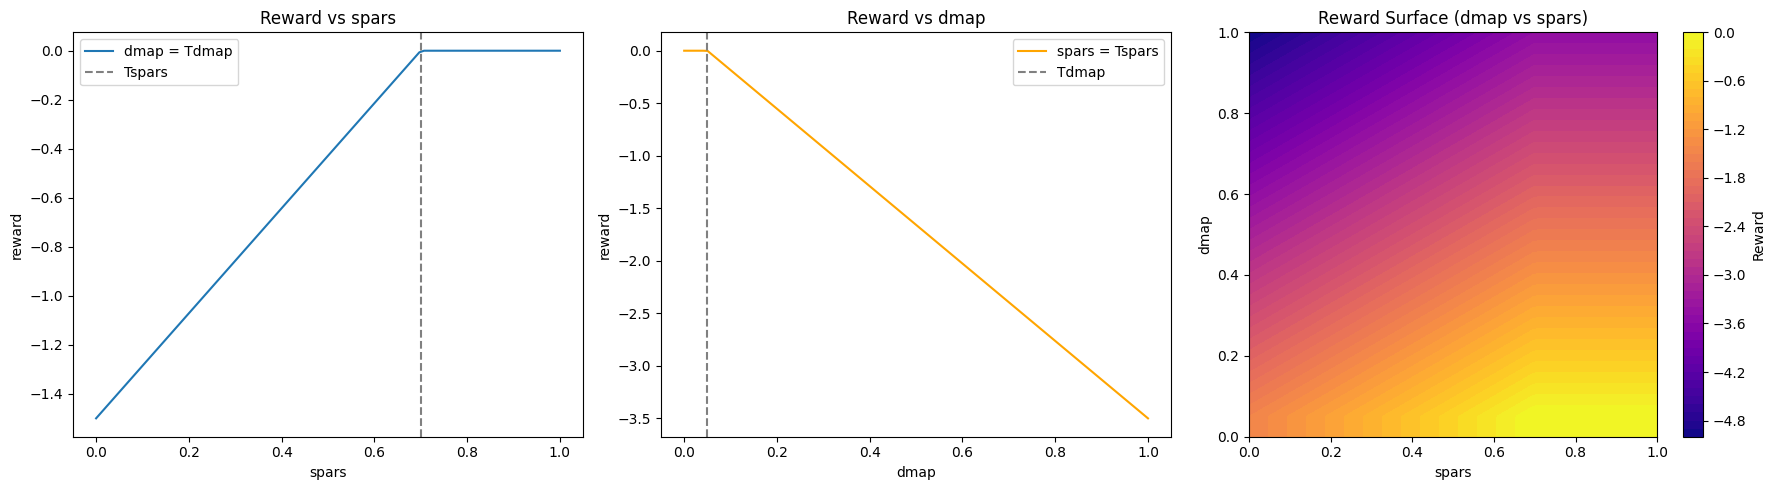

In [44]:
Tspars = 0.7
Tdmap = 0.05
spars_coeff = 0.3
dmap_coeff = 0.7
beta = 5

plot_reward_surface(Tspars, Tdmap, spars_coeff, dmap_coeff, beta)

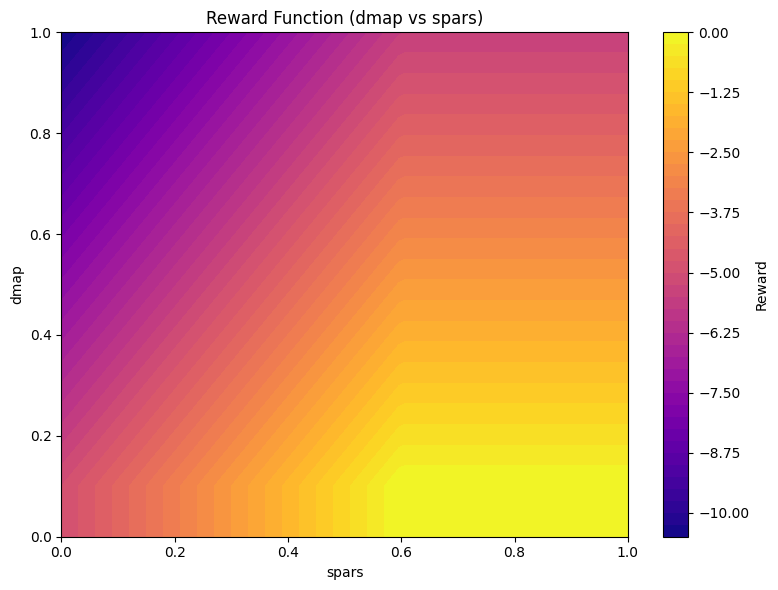

In [25]:
plot_reward_surface()